In [11]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict
from IPython.display import Image

In [22]:
class BMIState(TypedDict):
    weight_kg : float
    hight_m : float
    bmi : float
    category: str

In [23]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    hight = state['hight_m']

    bmi = weight/(hight**2)

    state['bmi'] = round(bmi,2)
    return state

In [24]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "underweight"
    elif 18.5 <= bmi <25:
        state['category'] = "Normal"
    elif 25<= bmi <30:
        state['category'] = "overwright"
    else:
        state['category'] = "Obese"
    return state

In [25]:
graph = StateGraph(BMIState)

graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge('label_bmi', END)

workflow = graph.compile()

In [26]:
intial_state = {'weight_kg':80, 'hight_m':1.72}
final_state = workflow.invoke(intial_state)
print(final_state)

{'weight_kg': 80, 'hight_m': 1.72, 'bmi': 27.04, 'category': 'overwright'}


In [27]:
workflow.get_graph().draw_mermaid_png()

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\x90\x00\x00\x01M\x08\x02\x00\x00\x00`\xf3q\xaa\x00\x00\x10\x00IDATx\x9c\xec\x9d\x07|\x14E\xfb\xc7g\xaf\xdf\xa5\xf7\x84\xf4\x10$\x90\x80\x01C\x13)!\x04\x15PBQ\x10\xa5DA\x03\xc2K\x15D@\xba(Ey\x11\xc1\x17\x01\x91^\xfd\x03"\x1d\x01\xa5\xf7^$\x90\x06\xa4@\xea]\x92+\xb9\xdd\xffswp\xb9\xe4\xee\xd2\xd8\xbdd7\xf3%\x9fcov\xb6\xdc\xfevf\x9ei\xcf\x08(\x8aB\x18\xf6 @\x18V\x81\x05c\x19X0\x96\x81\x05c\x19X0\x96\x81\x05c\x19\xb5&\xd8\x8d\x93\xb9\xa9w\x8b\x14\x05Z\xad\x86\xd4\xa8-\xc5 \x08\xa4\xabq\x94\xd6:\x08\x1e\xa2H\xdd\'\x84\x99WFt\xd1)\xc3\x06a\xac\xab@d\x02\x11$Y&6\x0f\xce\x03\x91\xb5\x96\x0f7\xc2\xe7\xf1\xb4$i\x1aE \xa0\x84b\x9e\x93\x870$\xc2\xaeQ\x0bGT\x1b\x106\xae\x87\xfd\xb5%3\xe9v\xa1\xb2\x90\x84\xa7\x06?^(&\xf8|\x82,!\xccc\xc2\xb3\x86\xc7E\x94\r1\x08\xa6\xbbe\xf3\xbb&(\x9d\x0e\xba\x8d\xd2\xbd:u\x91\xee\xa8\xb21\xf5\xf2\x94\x0b\xd4\x9d\x95(s\x1f|\x02iM.C\x91\x84\x80\xd0\xa8)\xdd\x1b\xa6\x82\xb8\xc8\xce\x89\xdf\xb4\xadc\xabX7dCl\'\xd8\xc1\xf5

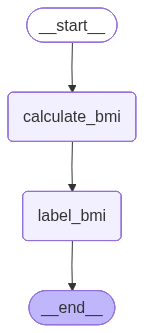

In [28]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())